In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

In [4]:
X_customers, _ = make_blobs(n_samples=200, n_features=2, centers=3, cluster_std=3.0, random_state=42)

# Scale the data so it looks like Age (18-70) and Spending Score (1-100)
X_customers[:, 0] = np.interp(X_customers[:, 0], (X_customers[:, 0].min(), X_customers[:, 0].max()), (18, 70))
X_customers[:, 1] = np.interp(X_customers[:, 1], (X_customers[:, 1].min(), X_customers[:, 1].max()), (1, 100))

In [5]:
k = 3
np.random.seed(7)
centroids = X_customers[np.random.choice(X_customers.shape[0], k, replace=False)]

for _ in range(10):
    # Assignment Step
    labels = np.array([np.argmin(np.sqrt(np.sum((point - centroids) ** 2, axis=1))) for point in X_customers])
    # Update Step
    centroids = np.array([X_customers[labels == i].mean(axis=0) for i in range(k)])

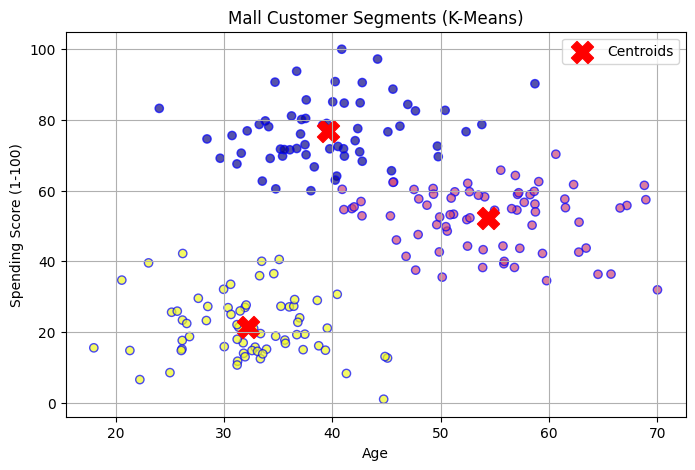

In [6]:
for _ in range(10):
    # Assignment Step
    labels = np.array([np.argmin(np.sqrt(np.sum((point - centroids) ** 2, axis=1))) for point in X_customers])
    # Update Step
    centroids = np.array([X_customers[labels == i].mean(axis=0) for i in range(k)])

# 3. Plot the Business Segments
plt.figure(figsize=(8, 5))
plt.scatter(X_customers[:, 0], X_customers[:, 1], c=labels, cmap='plasma', alpha=0.7, edgecolors='b')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=250, label='Centroids')
plt.title("Mall Customer Segments (K-Means)")
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.grid(True)
plt.show()